# Chapter 2: Centroid Clustering

This notebook accompanies **Chapter 2** of the lecture notes.

**Agenda**

☕ · 🎯 · 🔄 · 📦 · 🏆 · 📐 · 🏁

**Next steps (take it from here):** 🔖 · 💎 · ⚡ · 🧩

> **Tip:** Run cells top to bottom. Later cells depend on earlier ones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys; sys.path.insert(0, '../..')
from plot_style import *
from checks import (
    check_assign_clusters, check_update_centroids,
    check_inertia, check_silhouette,
    check_kmeans_pp_init, check_kmedoids_assign,
    check_kmedoids_update, check_minibatch_step,
)

## ☕ The Coffee Lab: Scaled Up

Your coffee quality lab has been brought in as a partner on a large research project. A consortium of roasters has sent over **1 797 aroma fingerprints** collected from ten brewing methods. Each fingerprint was originally captured as a 64-channel sensor reading: one intensity per frequency band in the aroma spectrum. A colleague has already compressed each 64-dimensional reading down to two summary coordinates, a technique you will derive yourself in a later chapter. For now, you receive the 2D coordinates and the question:

**Can you recover the ten brewing groups from the fingerprints alone, without ever seeing the labels?**

> The scatter plot below colors each sample by its true brewing method. In real lab work you would not have these labels: that is precisely why you need a clustering algorithm. As you look at the point cloud, notice that some varieties form tight, isolated islands while others overlap heavily. What does that tell you about which groups K-Means will recover cleanly and which it will struggle with?

<details><summary>Thought</summary>

K-Means assigns each point to the nearest centroid and assumes clusters are roughly spherical and equally sized. Tight, well-separated groups: where the within-group spread is small relative to the between-group distance: will snap cleanly to their centroid. Overlapping or elongated groups will be split or merged depending on where the centroids happen to land. The fact that some varieties overlap in this 2D fingerprint does not necessarily mean the varieties are similar: it may simply mean that two dimensions cannot fully capture a 64-dimensional difference. K-Means does not know this and will draw a straight boundary regardless.
</details>

In [2]:
# Load the aroma fingerprint dataset
df      = pd.read_csv('coffee_aroma_2d.csv')
X       = df[['x1', 'x2']].values          # 2D coordinates, shape (1797, 2)
labels  = df['variety'].values              # brewing method labels

varieties = list(dict.fromkeys(labels))     # preserve order of first appearance
print(f'Samples  : {len(X)}')
print(f'Features : 2 (compressed aroma coordinates)')
print(f'Varieties: {len(varieties)}')
print()
print(df['variety'].value_counts().sort_index().to_string())

Samples  : 1797
Features : 2 (compressed aroma coordinates)
Varieties: 10

variety
americano       183
cappuccino      181
cold_brew       179
espresso        178
flat_white      181
french_press    180
latte           182
lungo           177
pour_over       174
ristretto       182


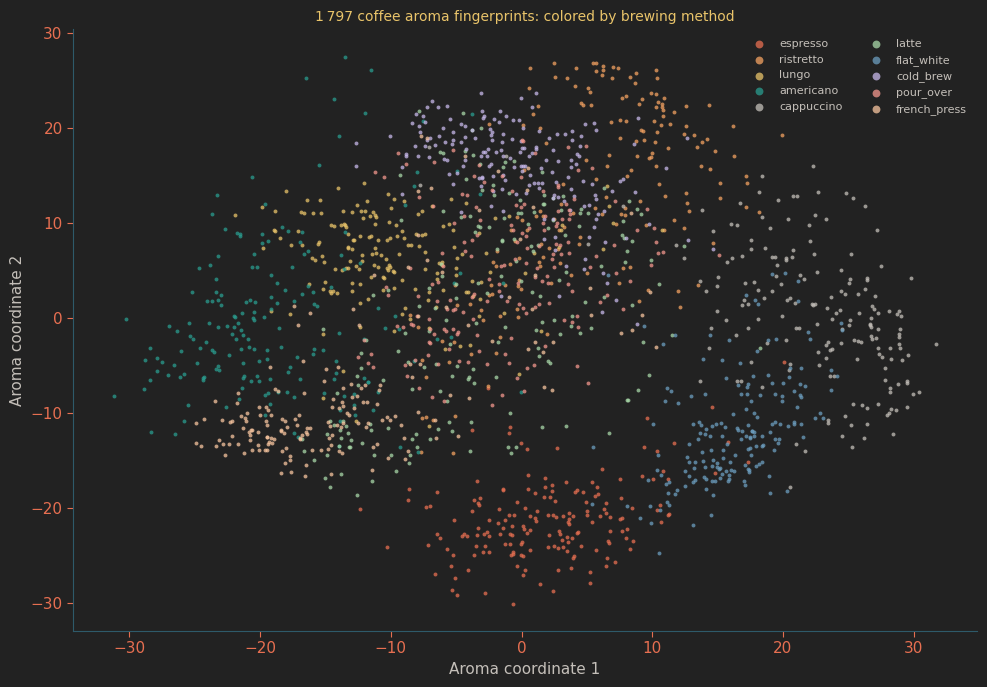

In [3]:
# Assign a distinct color to each brewing method
_variety_colors = {
    'espresso'   : _TERRA,
    'ristretto'  : _ORANGE,
    'lungo'      : _GOLDEN,
    'americano'  : _ACCENT,
    'cappuccino' : _TEXT,
    'latte'      : '#a8d8a8',
    'flat_white' : '#6c9ebf',
    'cold_brew'  : '#c7b8ea',
    'pour_over'  : '#f4978e',
    'french_press': '#f7c59f',
}
colors = [_variety_colors[v] for v in labels]

fig, ax = plt.subplots(figsize=(10, 7))
for variety, color in _variety_colors.items():
    mask = labels == variety
    ax.scatter(X[mask, 0], X[mask, 1],
               c=color, s=8, linewidths=0, label=variety, alpha=0.75)

ax.set_xlabel('Aroma coordinate 1')
ax.set_ylabel('Aroma coordinate 2')
ax.set_title('1 797 coffee aroma fingerprints: colored by brewing method', fontsize=10)
ax.legend(ncol=2, frameon=False, fontsize=8, markerscale=2, labelcolor=_TEXT)
tufte_axis(ax)
plt.tight_layout()
plt.show()

**Observe:** Some brewing methods cluster tightly (espresso sits in a compact region) while others spread out or overlap (cappuccino and latte share aroma territory). Varieties like ristretto and lungo differ by extraction time: similar enough that their 2D fingerprints overlap even though a trained taster would distinguish them. This spread and overlap will limit what K-Means can recover, regardless of K.

The Euclidean distance function below is a reference implementation from Chapter 1. If you completed that notebook, paste your own version instead.

In [4]:
def euclidean_distance(x, y):
    """Return the Euclidean distance between two 1-D arrays."""
    return np.sqrt(np.sum((x - y) ** 2))

## 🎯 The Assignment Step

K-Means alternates between two steps until convergence. The first is the **assignment step**: every sample is assigned to the cluster of its nearest centroid. The collection of samples closest to each centroid forms a Voronoi cell in the feature space.

> In the lecture notes, K-Means is described as building a Voronoi partition: each centroid “owns” all points closer to it than to any other centroid. If you moved one centroid 1 cm to the right on this plot, roughly how much of the point cloud would change its assignment, and why does it depend on where that centroid sits?

<details><summary>Thought</summary>

A centroid sitting in a dense region: surrounded by many samples on all sides: has a large Voronoi cell. Moving it slightly shifts the cell boundaries, potentially reassigning many nearby points. A centroid at the edge of the data cloud has a smaller cell and fewer contested neighbors, so the same 1 cm shift reassigns fewer points. The assignment step is most sensitive to centroid positions near the natural boundaries between clusters, where many points sit approximately equidistant from two centroids.
</details>

Implement `assign_clusters`: for each row of `data`, return the index (0 to k−1) of the nearest centroid. Use **squared** Euclidean distance: the argmin is the same as with the full distance but avoids the square root.

Aim for a vectorized implementation: the elbow loop in 📐 will call this function dozens of times.

Useful operations: `data[:, None, :] - centroids[None, :, :]` broadcasts to shape `(n, k, d)`: all centroid offsets at once. `np.sum(..., axis=2)` collapses the feature axis to `(n, k)` squared distances. `np.argmin(..., axis=1)` picks the nearest centroid per row.

In [5]:
# Small test case: three clear coffee sample groups in 2D aroma space
_test_pts = np.array([[0.0, 0.0], [1.0, 0.5],
                      [4.0, 4.0], [5.0, 3.5],
                      [9.0, 0.5], [8.0, 1.0]])
_test_mu  = np.array([[0.5, 0.25], [4.5, 3.75], [8.5, 0.75]])


def assign_clusters(data, centroids):
    """Assign each sample to its nearest centroid.

    Parameters
    -------    data      : ndarray, shape (n, d)
    centroids : ndarray, shape (k, d)

    Returns
    ----    assignments : ndarray of int, shape (n,)
        assignments[i] is the index of the closest centroid to data[i].
    """
    # Step 1: compute squared distances from every sample to every centroid, shape (n, k)
    #         use broadcasting:
    #           data[:, None, :]       shape (n, 1, d)
    #           centroids[None, :, :]  shape (1, k, d)
    #         subtract, square, sum over axis=2

    # Step 2: return the argmin along axis=1 to get the nearest centroid per sample


check_assign_clusters(assign_clusters, _test_pts, _test_mu)

  ⬜ assign_clusters: not implemented yet


In [6]:
# Visualize one assignment step: 400 fingerprints, K = 5 random centroids
rng_vis = np.random.default_rng(7)
k_vis   = 5
X_vis   = X[:400]
mu_init = X_vis[rng_vis.choice(len(X_vis), k_vis, replace=False)].copy()

if assign_clusters(X_vis[:2], mu_init) is not None:
    asgn_vis = assign_clusters(X_vis, mu_init)
    _pal5 = [_ACCENT, _GOLDEN, _ORANGE, _TERRA, _TEXT]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.scatter(X_vis[:, 0], X_vis[:, 1], c=_TEXT, s=8, linewidths=0, alpha=0.5)
    ax1.scatter(mu_init[:, 0], mu_init[:, 1], c=_pal5,
                s=120, marker='x', linewidths=2, zorder=5)
    ax1.set_title('Before assignment: random centroids', fontsize=10)
    ax1.set_xlabel('Aroma coord. 1'); ax1.set_ylabel('Aroma coord. 2')
    tufte_axis(ax1)

    ax2.scatter(X_vis[:, 0], X_vis[:, 1],
                c=[_pal5[a] for a in asgn_vis], s=8, linewidths=0, alpha=0.5)
    ax2.scatter(mu_init[:, 0], mu_init[:, 1], c=_pal5,
                s=120, marker='x', linewidths=2, zorder=5)
    ax2.set_title('After assignment: each sample colored by nearest centroid', fontsize=10)
    ax2.set_xlabel('Aroma coord. 1')
    tufte_axis(ax2)

    plt.tight_layout()
    plt.show()
else:
    print('⬜ Implement assign_clusters first.')

⬜ Implement assign_clusters first.


## 🔄 The Update Step

After assigning samples to clusters, each centroid moves to the **mean** of its assigned samples. This is the update step: because the arithmetic mean is the unique minimizer of squared error, it gives the centroid position that minimizes the within-cluster sum of squares for the current assignment.

> The updated centroid is the aroma “center of mass” of its cluster: it need not correspond to any real coffee sample. If you wanted to present a concrete example fingerprint as the cluster representative (say, to label the shelf in a retail context), what would you use instead?

<details><summary>Thought</summary>

The **medoid**: the cluster member whose total distance to all other members is smallest. Unlike the mean, the medoid is always an actual measured sample: a real fingerprint you could present to a customer. For the coffee lab, a medoid representative is interpretable: it is a real brewing result, not an averaged one that might correspond to no achievable cup. This variant is K-Medoids, covered in the optional section at the end.
</details>

Implement `update_centroids`: for each cluster `i`, compute the mean position of all samples currently assigned to it.

Useful operations: `data[assignments == i]` selects only the rows belonging to cluster `i`. `.mean(axis=0)` computes the column-wise mean of the selected rows.

In [7]:
# First two samples → cluster 0, next two → cluster 1, last two → cluster 2
_test_labels = np.array([0, 0, 1, 1, 2, 2])


def update_centroids(data, assignments, k):
    """Recompute each centroid as the mean of its assigned samples.

    Parameters
    -------    data        : ndarray, shape (n, d)
    assignments : ndarray of int, shape (n,)
    k           : int: number of clusters

    Returns
    ----    centroids : ndarray, shape (k, d)
    """
    # Step 1: for each cluster i in range(k), select rows where assignments == i
    # Step 2: compute the mean of those rows along axis=0
    # Step 3: collect into an array of shape (k, d) and return
    #         Hint: np.array([data[assignments == i].mean(axis=0) for i in range(k)])


check_update_centroids(update_centroids, _test_pts, _test_labels, 3)

  ⬜ update_centroids: not implemented yet


## 📦 Putting It Together: K-Means

The two steps (assign then update) repeat until the assignments stop changing. Convergence is guaranteed in finite steps: each step can only decrease or maintain inertia, and the number of distinct assignment configurations is finite, so the algorithm cannot cycle indefinitely.

The function below combines your two implementations into a complete K-Means run. Read through it before using it in later cells.

In [8]:
def kmeans(data, k, max_iter=300, seed=None):
    """Run K-Means with random initialization.

    Returns
    ----    centroids   : ndarray, shape (k, d) : converged centroids
    assignments : ndarray of int, shape (n,) : final cluster labels
    n_iter      : int : number of assign/update cycles until convergence
    """
    if assign_clusters(_test_pts[:2], _test_mu[:2]) is None:
        return None, None, 0
    if update_centroids(_test_pts, _test_labels, 3) is None:
        return None, None, 0

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(data), k, replace=False)
    centroids   = data[idx].copy()
    assignments = np.full(len(data), -1, dtype=int)

    for it in range(max_iter):
        new_assignments = assign_clusters(data, centroids)
        if np.array_equal(new_assignments, assignments):
            break
        assignments = new_assignments
        centroids   = update_centroids(data, assignments, k)

    return centroids, assignments, it + 1

In [9]:
# Watch K-Means converge step by step on 300 fingerprints
rng_trace = np.random.default_rng(12)
k_trace   = 4
X_trace   = X[:300]
idx0      = rng_trace.choice(len(X_trace), k_trace, replace=False)
_pal4     = [_ACCENT, _GOLDEN, _ORANGE, _TERRA]
snap_iters = [0, 1, 2, 15]

if assign_clusters(X_trace[:2], X_trace[:k_trace]) is not None:
    fig, axes = plt.subplots(1, len(snap_iters), figsize=(14, 4))

    for snap_i, stop_at in enumerate(snap_iters):
        mu_s   = X_trace[idx0].copy()
        asgn_s = np.full(len(X_trace), -1, dtype=int)

        for it in range(stop_at + 1):
            new_a = assign_clusters(X_trace, mu_s)
            if np.array_equal(new_a, asgn_s):
                break
            asgn_s = new_a
            if it < stop_at:
                mu_s = update_centroids(X_trace, asgn_s, k_trace)

        ax = axes[snap_i]
        ax.scatter(X_trace[:, 0], X_trace[:, 1],
                   c=[_pal4[a] for a in asgn_s], s=8, linewidths=0, alpha=0.7)
        ax.scatter(mu_s[:, 0], mu_s[:, 1], c=_pal4,
                   s=100, marker='x', linewidths=2, zorder=5)
        ax.set_title(f'Iteration {stop_at}', fontsize=10)
        ax.set_xlabel('Aroma coord. 1')
        if snap_i == 0:
            ax.set_ylabel('Aroma coord. 2')
        tufte_axis(ax)

    plt.tight_layout()
    plt.show()
else:
    print('⬜ Implement assign_clusters and update_centroids first.')

⬜ Implement assign_clusters and update_centroids first.


## 🏆 Multiple Runs: Initialization Sensitivity

K-Means converges to a local minimum, not necessarily the global one. A bad initialization: two starting centroids placed inside the same natural cluster: produces a partition that never recovers, no matter how many iterations run. The standard remedy is to run K-Means several times with different random seeds and keep the result with the lowest inertia.

> You run K-Means 20 times on the same aroma fingerprints and get 20 different inertia values. Convergence is guaranteed every time, yet results differ. Two runs converge to the same fixed point even though they started from different positions. Is that possible? Under what conditions?

<details><summary>Thought</summary>

Yes, it is possible. Two initializations in the same basin of attraction will follow different paths but converge to the same fixed point: the same centroid positions and assignments. The inertia landscape has many local minima, each at the bottom of a basin. Different seeds explore different basins, but seeds within the same basin converge to the same result. With enough natural cluster separation, most seeds land in the same basin and most runs agree. With overlapping or ambiguous clusters: like some of our brewing varieties: the landscape is flatter and multiple basins of similar depth produce noticeably different inertias.
</details>

To compare runs you need to measure solution quality. Implement `compute_inertia`: the **within-cluster sum of squares**: the sum over every sample of the squared Euclidean distance to its assigned centroid.

Revisit the lecture notes for the formula. Useful operations: `data[assignments == k] - centroids[k]` selects the cluster members and centers them on the centroid, `** 2` squares element-wise, `np.sum()` totals everything.

In [10]:
_test_mu_final = np.array([[0.5, 0.25], [4.5, 3.75], [8.5, 0.75]])


def compute_inertia(data, assignments, centroids):
    """Return the within-cluster sum of squares (WCSS / inertia).

    Parameters
    -------    data        : ndarray, shape (n, d)
    assignments : ndarray of int, shape (n,)
    centroids   : ndarray, shape (k, d)

    Returns
    ----    J : float
    """
    # Step 1: for each cluster i in range(len(centroids)):
    #   - select data[assignments == i]
    #   - subtract centroids[i] from each row
    #   - compute the sum of squared distances for that cluster
    # Step 2: sum over all clusters and return as float


check_inertia(compute_inertia, _test_pts, _test_labels, _test_mu_final)

  ⬜ compute_inertia: not implemented yet


In [11]:
# Run K-Means 20 times with K = 10 and compare inertia across runs
_J_test = compute_inertia(_test_pts, _test_labels, _test_mu_final)

if _J_test is not None:
    k_runs   = 10
    n_runs   = 20
    inertias = []

    for seed in range(n_runs):
        mu, asgn, _ = kmeans(X, k_runs, seed=seed)
        if mu is not None:
            J = compute_inertia(X, asgn, mu)
            if J is not None:
                inertias.append(J)

    if inertias:
        inertias  = np.array(inertias)
        best_idx  = int(np.argmin(inertias))
        bar_cols  = [_ACCENT if i == best_idx else _BORDER for i in range(len(inertias))]

        fig, ax = plt.subplots(figsize=(11, 4))
        ax.bar(range(len(inertias)), inertias, color=bar_cols, linewidth=0)
        ax.set_xlabel('Run (different random seed)')
        ax.set_ylabel('Inertia (WCSS)')
        ax.set_title(f'K = {k_runs}: inertia across {n_runs} random initializations', fontsize=10)
        ax.annotate(f'Best\n{inertias[best_idx]:.0f}',
                    xy=(best_idx, inertias[best_idx]),
                    xytext=(best_idx + 0.8, inertias[best_idx] * 1.008),
                    color=_ACCENT, fontsize=8,
                    arrowprops=dict(arrowstyle='->', color=_ACCENT, lw=0.8))
        tufte_axis(ax)
        plt.tight_layout()
        plt.show()

        spread = (inertias.max() - inertias.min()) / inertias.min()
        print(f'Inertia range: {inertias.min():.0f} to {inertias.max():.0f}')
        print(f'Worst run is {spread:.1%} above the best: initialization matters.')
else:
    print('⬜ Implement compute_inertia first.')

⬜ Implement compute_inertia first.


## 📐 Elbow Method: Choosing K

K must be chosen before running K-Means. The **elbow method** plots inertia against K and looks for a kink: the point where adding one more cluster yields diminishing returns. Before that kink, each new cluster captures genuine structure; after it, you are mainly splitting an existing group in two.

> Inertia always decreases as K increases: at K = n, every sample is its own cluster and inertia is zero. This makes raw inertia useless as a stopping criterion. What exactly does the elbow method measure, and why is the rate of change more informative than the value itself?

<details><summary>Thought</summary>

The elbow method looks at the marginal inertia reduction: how much does adding one more cluster buy you? When K is below the true number of groups, adding a cluster crosses a genuine boundary between natural groups and inertia drops sharply. Once K matches or exceeds the true number, additional clusters merely subdivide existing compact groups: the improvement per cluster becomes roughly constant and small. The kink is the transition between these two regimes. If the data has no discrete cluster structure (e.g. uniform noise), there is no kink and the curve decreases smoothly: the method gives no answer.
</details>

Fill in the loop: for each K, run K-Means `n_runs_elbow` times with different seeds and record the best (minimum) inertia.

In [12]:
k_max        = 15
n_runs_elbow = 3   # restarts per K
inertia_by_k = []  # append one float per K value

_J_test2 = compute_inertia(_test_pts, _test_labels, _test_mu_final)

if _J_test2 is not None:
    for k in range(1, k_max + 1):
        # YOUR CODE HERE
        # 1. Run kmeans(X, k, seed=s) for s in range(n_runs_elbow)
        # 2. For each run, call compute_inertia on the result
        # 3. Keep the minimum inertia across runs
        # 4. Append that minimum to inertia_by_k
        inertia_by_k.append(None)  # replace with the computed value

    n_done = sum(v is not None for v in inertia_by_k)
    print(f'{n_done}/{k_max} K values computed')
    if n_done > 0:
        print('Inertias:', [f'{v:.0f}' for v in inertia_by_k if v is not None])
else:
    print('⬜ Implement compute_inertia first.')

⬜ Implement compute_inertia first.


In [13]:
if len(inertia_by_k) == k_max and all(v is not None for v in inertia_by_k):
    ks = list(range(1, k_max + 1))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ks, inertia_by_k,
            color=_ACCENT, linewidth=1.5,
            marker='o', markersize=4,
            markerfacecolor=_GOLDEN, markeredgewidth=0)

    # Mark the true number of brewing varieties
    ax.axvline(10, color=_TERRA, linewidth=0.8, linestyle='--')
    ax.text(10.2, inertia_by_k[0] * 0.88,
            'K = 10\n(true varieties)', color=_TERRA, fontsize=8)

    ax.set_xlabel('K (number of clusters)')
    ax.set_ylabel('Best inertia (WCSS)')
    ax.set_title('Elbow plot for coffee aroma fingerprints', fontsize=10)
    ax.set_xticks(ks)
    tufte_axis(ax)
    plt.tight_layout()
    plt.show()

    print('▶ Where does the curve bend? Compare it to the dashed line at K = 10.')
else:
    print('⬜ Fill in the elbow loop above first.')

⬜ Fill in the elbow loop above first.


### 🏁 Recap

**What we did:**
- ☕ Loaded 1 797 two-dimensional aroma fingerprints from 10 brewing varieties and visualized the true groupings.
- 🎯 Implemented the K-Means assignment step: each sample snaps to its nearest centroid.
- 🔄 Implemented the update step: centroids move to cluster means.
- 📦 Combined both steps into a complete K-Means driver and watched convergence unfold.
- 🏆 Implemented inertia (WCSS), ran 20 random initializations, and saw how much results vary.
- 📐 Built the elbow plot for K = 1–15 and identified the kink relative to the ground-truth K = 10.

**Key takeaways:**
- K-Means always converges but finds a local, not global, optimum: multiple restarts are essential.
- The elbow method catches diminishing inertia returns and is a good first heuristic for choosing K.
- Silhouette score adds separation awareness on top of compactness: try it in the optional section.

**Now head back for self-check questions and key learnings in the lecture notes.**

## Take It from Here: Next Steps (Optional)

The exercises below are **optional** extensions. They are not required to follow the rest of the course. Work through them at your own pace after the session.

## 🔖 Silhouette Score: A Better K Selector

Inertia measures compactness within clusters but ignores the distances between clusters. Two very tight clusters placed almost on top of each other have low inertia but poor cluster structure: any sample near the boundary belongs ambiguously to both. The **silhouette score** captures this: for each sample it compares its cohesion inside its assigned cluster to its separation from the nearest other cluster.

For sample $x_i$ in cluster $C_k$:
- $a(i)$ = mean distance to all **other** samples in $C_k$ (cohesion)
- $b(i)$ = mean distance to all samples in the nearest other cluster (separation)
- $s(i) = \frac{b(i) - a(i)}{\max(a(i),\; b(i))}$

$s(i)$ is in $[-1, +1]$: near $+1$ means the sample sits deep inside its cluster and far from all others; near $0$ means it is on a boundary; negative means it would fit better in a different cluster.

> Inertia is minimized by making clusters as small and tight as possible, regardless of how close together those clusters are. Can you construct a scenario where inertia is very low but almost every silhouette value is negative?

<details><summary>Thought</summary>

Yes. Imagine K = 100 on a dataset of 200 coffee samples that naturally form 2 well-separated groups. Each tiny cluster has very low within-cluster spread (low inertia), but each cluster's nearest neighbor is another tiny cluster from the same original group, sitting just millimeters away in aroma space. So $b(i)$ is tiny: nearly as small as $a(i)$: and silhouette collapses toward zero or below. You over-segmented: the algorithm found 100 tight clusters where only 2 exist, and the silhouette correctly tells you the clusters are not well-separated.
</details>

Implement `silhouette_score_manual` on a 200-sample subset (silhouette requires O(n²) distance computations, which is slow on the full 1 797 samples).

For a singleton cluster (a sample that is the only member of its cluster), set $s(i) = 0$ by convention.

Useful operations: `data[assignments == c] - data[i]` gives displacement vectors to all cluster-c members. `np.sqrt(np.sum(..., axis=1))` computes row-wise Euclidean distances.

In [14]:
# 200-sample subset; run K-Means once to get test assignments
_n_sub = 200
X_sub  = X[:_n_sub]

_mu_sub, _asgn_sub, _ = kmeans(X_sub, k=10, seed=0) \
    if assign_clusters(X_sub[:2], X_sub[:3]) is not None \
    else (None, None, 0)


def silhouette_score_manual(data, assignments):
    """Return the mean silhouette score over all samples.

    Parameters
    -------    data        : ndarray, shape (n, d)
    assignments : ndarray of int, shape (n,)

    Returns
    ----    score : float in [-1, +1]
    """
    # Step 1: get k = number of clusters, n = number of samples;
    #         initialise s_vals = np.zeros(n)

    # Step 2: for each sample i:
    #   a. c_i = assignments[i]
    #   b. a(i): mean Euclidean distance from i to all OTHER samples in cluster c_i
    #      - build a boolean mask for same-cluster samples, excluding i itself
    #      - if no other same-cluster samples exist, set s_vals[i] = 0 and continue
    #      - distance to each: np.sqrt(np.sum((data[mask] - data[i])**2, axis=1))
    #   c. b(i): for each other cluster c != c_i,
    #            compute mean distance from i to all samples in c;
    #            b(i) = minimum of those mean distances
    #   d. s_vals[i] = (b(i) - a(i)) / max(a(i), b(i))   (0 if denominator is 0)

    # Step 3: return float(np.mean(s_vals))


if _asgn_sub is not None:
    check_silhouette(silhouette_score_manual, X_sub, _asgn_sub)
else:
    print('⬜ Implement assign_clusters and update_centroids first.')

⬜ Implement assign_clusters and update_centroids first.


In [15]:
# Compare elbow and silhouette side by side for K = 2..12
_sil_test = silhouette_score_manual(X_sub, _asgn_sub) if _asgn_sub is not None else None
_ib_ok    = all(v is not None for v in inertia_by_k)

if _sil_test is not None and _ib_ok:
    k_range    = range(2, 13)
    sil_scores = []

    for k in k_range:
        best_sil = -np.inf
        for seed in range(3):
            mu_k, asgn_k, _ = kmeans(X_sub, k, seed=seed)
            if mu_k is None:
                break
            s = silhouette_score_manual(X_sub, asgn_k)
            if s is not None and s > best_sil:
                best_sil = s
        sil_scores.append(best_sil if best_sil > -np.inf else None)

    if all(s is not None for s in sil_scores):
        k_list = list(k_range)
        ks     = list(range(1, k_max + 1))
        best_k = k_list[int(np.argmax(sil_scores))]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        ax1.plot(ks, inertia_by_k,
                 color=_ACCENT, linewidth=1.5,
                 marker='o', markersize=4,
                 markerfacecolor=_GOLDEN, markeredgewidth=0)
        ax1.axvline(10, color=_TERRA, linewidth=0.8, linestyle='--')
        ax1.set_xlabel('K')
        ax1.set_ylabel('Best inertia (WCSS)')
        ax1.set_title('Elbow method', fontsize=10)
        ax1.set_xticks(ks)
        tufte_axis(ax1)

        ax2.plot(k_list, sil_scores,
                 color=_GOLDEN, linewidth=1.5,
                 marker='o', markersize=4,
                 markerfacecolor=_ACCENT, markeredgewidth=0)
        ax2.axvline(10, color=_TERRA, linewidth=0.8, linestyle='--')
        ax2.axvline(best_k, color=_GOLDEN, linewidth=0.8, linestyle=':')
        ax2.text(best_k + 0.15, max(sil_scores),
                 f'peak K = {best_k}', color=_GOLDEN, fontsize=8)
        ax2.set_xlabel('K')
        ax2.set_ylabel('Mean silhouette score')
        ax2.set_title('Silhouette method', fontsize=10)
        ax2.set_xticks(k_list)
        tufte_axis(ax2)

        plt.tight_layout()
        plt.show()

        print(f'Silhouette peaks at K = {best_k}. Dashed line marks K = 10 (true varieties).')
        print(f'Do the two methods agree? Why might they suggest different K values?')
else:
    print('⬜ Complete compute_inertia, the elbow loop, and silhouette_score_manual first.')

⬜ Complete compute_inertia, the elbow loop, and silhouette_score_manual first.


### 💎 K-Medoids: Real-Sample Representatives

K-Means centroids are arithmetic means: they often correspond to no real aroma fingerprint, being an average across many measurements. A centroid representing the “cappuccino cluster” may describe a coffee that has never actually been brewed. **K-Medoids** fixes this: the cluster representative is the **medoid**, the actual measured sample that minimizes total distance to all other cluster members.

> A K-Means centroid for the espresso cluster is the mean pixel-averaged fingerprint: possibly an impossible cup. A K-Medoids medoid is a real espresso that was measured. When would you prefer a medoid over a centroid, and at what computational cost?

<details><summary>Thought</summary>

Medoids are preferable whenever the representative must be a real, reproducible sample: for example, when you want to send a reference bottle to each of ten partner roasters to calibrate their instruments. K-Means centroids can sit in empty aroma space with no corresponding brew. The cost: finding the medoid requires pairwise distances within each cluster, making each update step O(n²) per cluster rather than O(n). For 1 797 samples this is still fast; for millions of samples you need approximate methods like CLARA.
</details>

Implement the two K-Medoids steps. **`kmedoids_assign`** is almost identical to `assign_clusters` but receives data *indices* rather than coordinates. **`kmedoids_update`** finds the global index of the true medoid for each cluster.

In [16]:
_med_idx_test = np.array([0, 2, 4])


def kmedoids_assign(data, medoid_indices):
    """Assign each sample to the nearest medoid.

    Parameters
    -------    data          : ndarray, shape (n, d)
    medoid_indices: 1-D array of int: indices into data

    Returns
    ----    assignments : ndarray of int, shape (n,)
    """
    # Step 1: extract the medoid rows: medoids = data[medoid_indices], shape (k, d)

    # Step 2: compute squared distances (n, k) using broadcasting (same pattern as assign_clusters)

    # Step 3: return np.argmin(dists, axis=1)


check_kmedoids_assign(kmedoids_assign, _test_pts, _med_idx_test)

  ⬜ kmedoids_assign: not implemented yet


In [17]:
def kmedoids_update(data, assignments, k):
    """Find the medoid index for each cluster.

    The medoid of cluster C_k is the member of C_k that minimizes
    the sum of squared distances to all other members of C_k.

    Parameters
    -------    data        : ndarray, shape (n, d)
    assignments : ndarray of int, shape (n,)
    k           : int

    Returns
    ----    medoid_indices : ndarray of int, shape (k,)
        Global indices into data.
    """
    # Step 1: initialise result = np.zeros(k, dtype=int)

    # Step 2: for each cluster in range(k):
    #   - find global indices of assigned samples: np.where(assignments == cluster)[0]
    #   - if empty, set result[cluster] = -1 and continue
    #   - extract cluster_data = data[indices]
    #   - compute all pairwise squared distances within cluster_data using broadcasting
    #   - sum each row to get total distance from that candidate to all cluster members
    #   - local_idx = np.argmin of those row sums
    #   - result[cluster] = indices[local_idx]  (convert back to global index)

    # Step 3: return result


check_kmedoids_update(kmedoids_update, _test_pts, _test_labels, 3)

  ⬜ kmedoids_update: not implemented yet


In [18]:
def kmedoids(data, k, max_iter=100, seed=None):
    if kmedoids_assign(data[:2], np.array([0, 1])) is None:
        return None, None
    if kmedoids_update(data[:6], np.array([0,0,1,1,2,2]), 3) is None:
        return None, None
    rng     = np.random.default_rng(seed)
    med_idx = rng.choice(len(data), k, replace=False)
    for _ in range(max_iter):
        assignments = kmedoids_assign(data, med_idx)
        new_med_idx = kmedoids_update(data, assignments, k)
        if np.array_equal(new_med_idx, med_idx):
            break
        med_idx = new_med_idx
    return med_idx, assignments


# Compare K-Means vs K-Medoids when outliers are present
rng_out = np.random.default_rng(99)
X_out   = X[:300].copy()
outlier_scale = X_out.max(axis=0) * 3
X_out[:5] = rng_out.uniform(outlier_scale * 0.8, outlier_scale, size=(5, 2))

med_idx, asgn_med = kmedoids(X_out, k=4, seed=0)
mu_km, asgn_km, _ = kmeans(X_out, k=4, seed=0)

if med_idx is not None and mu_km is not None:
    _pal4 = [_ACCENT, _GOLDEN, _ORANGE, _TERRA]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.scatter(X_out[:, 0], X_out[:, 1],
                c=[_pal4[a] for a in asgn_km], s=10, linewidths=0, alpha=0.7)
    ax1.scatter(mu_km[:, 0], mu_km[:, 1], c=_pal4,
                s=120, marker='x', linewidths=2, zorder=5)
    ax1.set_title('K-Means: centroids pulled by outliers (×)', fontsize=10)
    ax1.set_xlabel('Aroma coord. 1'); ax1.set_ylabel('Aroma coord. 2')
    tufte_axis(ax1)

    medoids = X_out[med_idx]
    ax2.scatter(X_out[:, 0], X_out[:, 1],
                c=[_pal4[a] for a in asgn_med], s=10, linewidths=0, alpha=0.7)
    ax2.scatter(medoids[:, 0], medoids[:, 1], c=_pal4,
                s=80, marker='D', linewidths=0, zorder=5)
    ax2.set_title('K-Medoids: medoids anchored to real samples (◆)', fontsize=10)
    ax2.set_xlabel('Aroma coord. 1')
    tufte_axis(ax2)

    plt.tight_layout()
    plt.show()
    print('Observe: K-Means centroids drift toward the five extreme outliers;'
          ' K-Medoids stays anchored to actual measured samples.')
else:
    print('⬜ Implement kmedoids_assign and kmedoids_update first.')

⬜ Implement kmedoids_assign and kmedoids_update first.


### ⚡ K-Means++: Smarter Initialization

Random initialization often places two starting centroids inside the same natural cluster. K-Means++ fixes this probabilistically: the first centroid is chosen uniformly at random; each subsequent centroid is chosen with probability proportional to its **squared distance to the nearest already-chosen centroid**. Points far from all current centroids are more likely to be selected next, spreading the seeds across the data.

> The selection probability is proportional to squared distance, not raw distance. Why squared? What happens to a fingerprint that is extremely far from every existing centroid compared to one that is only moderately far?

<details><summary>Thought</summary>

Squaring is superlinear: doubling the distance quadruples the selection probability. This concentrates the selection on the most isolated points: the ones most likely to belong to an unexplored cluster. Under raw distance, a point ten times farther than another is only ten times more likely to be chosen; under squared distance it is a hundred times more likely. The squared form also aligns with the inertia objective, which is what makes the O(log K) theoretical bound on expected inertia possible.
</details>

Implement `kmeans_pp_init`: return `k` centroids selected from `data` using the K-Means++ seeding rule.

Useful operations: `np.min(..., axis=0)` to find the nearest centroid distance per point, `rng.choice(n, p=probs)` to sample proportionally to a probability vector.

In [19]:
def kmeans_pp_init(data, k, seed=None):
    """K-Means++ initialization.

    Parameters
    -------    data : ndarray, shape (n, d)
    k    : int
    seed : int or None

    Returns
    ----    centroids : ndarray, shape (k, d) : k rows selected from data
    """
    rng = np.random.default_rng(seed)

    # Step 1: choose the first centroid uniformly at random
    chosen_idx = [int(rng.choice(len(data)))]

    for _ in range(k - 1):
        # YOUR CODE HERE
        # 1. For each point, compute its squared distance to the nearest chosen centroid
        # 2. Normalize these distances to a probability distribution
        # 3. Sample the next index proportionally: rng.choice(len(data), p=probs)
        # 4. Append that index to chosen_idx
        pass

    return data[chosen_idx]


check_kmeans_pp_init(kmeans_pp_init, X, k=10)

  ❌ kmeans_pp_init: got shape (1, 2), expected (10, 2)
       Hint: return a (k, d) array of selected data points.


In [20]:
# Random vs K-Means++ initialization: 20 trials, K = 10
_pp_ok = kmeans_pp_init(X, k=3) is not None
_J_ok  = compute_inertia(_test_pts, _test_labels, _test_mu_final) is not None

if _pp_ok and _J_ok:
    k_cmp, n_cmp = 10, 20
    inertia_random, inertia_pp = [], []

    for seed in range(n_cmp):
        mu_r, asgn_r, _ = kmeans(X, k_cmp, seed=seed)
        if mu_r is not None:
            inertia_random.append(compute_inertia(X, asgn_r, mu_r))

        mu0 = kmeans_pp_init(X, k_cmp, seed=seed)
        if mu0 is not None:
            mu_pp, prev = mu0.copy(), np.full(len(X), -1, dtype=int)
            for _ in range(300):
                a = assign_clusters(X, mu_pp)
                if np.array_equal(a, prev): break
                prev  = a
                mu_pp = update_centroids(X, a, k_cmp)
            inertia_pp.append(compute_inertia(X, a, mu_pp))

    fig, ax = plt.subplots(figsize=(11, 4))
    xs = np.arange(n_cmp)
    ax.bar(xs - 0.2, inertia_random, 0.35, color=_BORDER,  label='Random init', linewidth=0)
    ax.bar(xs + 0.2, inertia_pp,     0.35, color=_ACCENT,  label='K-Means++ init', linewidth=0)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Inertia')
    ax.set_title(f'Random vs K-Means++ initialization, K = {k_cmp}', fontsize=10)
    ax.legend(frameon=False, fontsize=9, labelcolor=_TEXT)
    tufte_axis(ax)
    plt.tight_layout()
    plt.show()

    print(f'Random    , mean: {np.mean(inertia_random):.0f},  min: {np.min(inertia_random):.0f}')
    print(f'K-Means++ , mean: {np.mean(inertia_pp):.0f},  min: {np.min(inertia_pp):.0f}')
else:
    print('⬜ Implement kmeans_pp_init and compute_inertia first.')

⬜ Implement kmeans_pp_init and compute_inertia first.


### 🧩 Mini-Batch K-Means: Scale Up

Standard K-Means reads the entire dataset on every iteration. For a partner lab with millions of aroma fingerprints, that is prohibitively slow. **Mini-Batch K-Means** replaces each full-pass update with a centroid update computed from a small random **batch** of samples. Each batch gives a noisy estimate of the true cluster mean, but after many batches the centroids converge to roughly the same solution at a fraction of the cost.

> Standard K-Means computes exact cluster means; mini-batch K-Means computes means from a random subset. Why does averaging many noisy batch updates still converge, and what would happen if you used a batch size of 1?

<details><summary>Thought</summary>

Each mini-batch update is an unbiased estimate of the full cluster mean: the expected value of the batch mean equals the true cluster mean. By the law of large numbers, enough such updates drive the centroid toward its true position, just more slowly and noisily than the full-batch version. With batch size 1, every update is maximally noisy: the centroid jumps toward a single random sample each iteration. The algorithm can still converge (this is online K-Means), but very slowly and with high variance. Real implementations use exponential moving averages or learning rate schedules to stabilize the online updates.
</details>

Implement `minibatch_step`: given a random batch of samples, assign them to centroids and recompute each centroid as the mean of its assigned batch samples. If no batch sample landed in a cluster, keep that centroid unchanged.

In [21]:
def minibatch_step(batch, centroids):
    """One mini-batch centroid update.

    Parameters
    -------    batch     : ndarray, shape (b, d): a random subset of the data
    centroids : ndarray, shape (k, d)

    Returns
    ----    new_centroids : ndarray, shape (k, d)
    """
    # YOUR CODE HERE
    # 1. Assign batch samples to their nearest centroid (use assign_clusters)
    # 2. For each cluster, compute the mean of assigned batch samples
    #    (keep unchanged if no batch sample was assigned to that cluster)
    # 3. Return the updated centroids
    pass


_mb_centroids = np.array([[0.5, 0.25], [4.5, 3.75], [8.5, 0.75]])
check_minibatch_step(minibatch_step, _test_pts, _mb_centroids, batch_size=4)

  ⬜ minibatch_step: not implemented yet


In [22]:
def minibatch_kmeans(data, k, n_iter=200, batch_size=150, seed=None):
    if minibatch_step(_test_pts, _mb_centroids) is None:
        return None, None
    rng = np.random.default_rng(seed)
    centroids = data[rng.choice(len(data), k, replace=False)].copy()
    for _ in range(n_iter):
        batch     = data[rng.choice(len(data), batch_size, replace=False)]
        centroids = minibatch_step(batch, centroids)
    return centroids, assign_clusters(data, centroids)


# Speed vs quality: full K-Means vs mini-batch K-Means
_mb_ok = minibatch_step(_test_pts, _mb_centroids) is not None
_J_ok2 = compute_inertia(_test_pts, _test_labels, _test_mu_final) is not None

if _mb_ok and _J_ok2:
    import time
    k_cmp2, n_rep = 10, 5

    t0 = time.time()
    for seed in range(n_rep):
        mu_full, asgn_full, _ = kmeans(X, k_cmp2, seed=seed)
    t_full = (time.time() - t0) / n_rep
    J_full = compute_inertia(X, asgn_full, mu_full)

    t0 = time.time()
    for seed in range(n_rep):
        mu_mb, asgn_mb = minibatch_kmeans(X, k_cmp2, seed=seed)
    t_mb = (time.time() - t0) / n_rep
    J_mb = compute_inertia(X, asgn_mb, mu_mb)

    print(f'Full K-Means : {t_full*1000:.1f} ms/run,  inertia = {J_full:.0f}')
    print(f'Mini-Batch KM: {t_mb*1000:.1f} ms/run,  inertia = {J_mb:.0f}')
    if J_full and J_mb:
        excess  = (J_mb - J_full) / J_full
        speedup = t_full / t_mb if t_mb > 0 else float('inf')
        print(f'Inertia excess: {excess:+.1%}  |  Speedup: {speedup:.1f}×')
else:
    print('⬜ Implement minibatch_step, compute_inertia, and assign_clusters first.')

⬜ Implement minibatch_step, compute_inertia, and assign_clusters first.
